In [17]:
import os
import imgcompare
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

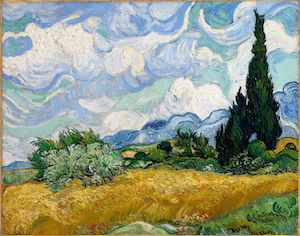

In [18]:
display(REFERENCE_IMAGE)

In [19]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [20]:
import os
import numpy as np
from time import time

import vangogh.variation as variation

os.makedirs("./img", exist_ok=True)


def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(
            evo.elite,
            evo.reference_image.width,
            evo.reference_image.height,
            scale=IMAGE_SHRINK_SCALE
        )

    if display_output:
        clear_output()
        display(elite)

    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(
            f"./img/van_gogh_intermediate_"
            f"{evo.seed}_{evo.population_size}_{evo.crossover_method}_"
            f"{evo.num_points}_{evo.initialization}_{evo.generation_budget}_"
            f"{time['num-generations']:05d}.png"
        )



#code developed with the assistance of LLMs
# ---------------------------------------------------------------------
# Original baseline wrapper: keep this for normal experiments
# ---------------------------------------------------------------------

def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()

    evo = Evolution(
        num_points,
        REFERENCE_IMAGE,
        population_size=population_size,
        generation_reporter=reporter,
        crossover_method=crossover_method,
        seed=seed,
        initialization=initialization,
        generation_budget=generation_budget,
        num_features_mutation_strength=.25,
        selection_name='tournament_4',
        verbose=verbose_output
    )

    data = evo.run()
    time_spent = time() - start

    print(
        f"Done: run {seed} - pop {population_size} - "
        f"crossover {crossover_method} - num. points {num_points} - "
        f"initialization {initialization} - in {int(time_spent)} seconds"
    )

    return data


# ---------------------------------------------------------------------
# Save original repo operators once
# ---------------------------------------------------------------------

if not hasattr(variation, "_original_crossover"):
    variation._original_crossover = variation.crossover

if not hasattr(variation, "_original_mutate"):
    variation._original_mutate = variation.mutate


# This flag lets us use split mutation only for the split experiment.
_USE_SPLIT_POSITION_COLOR_MUTATION = False


# ---------------------------------------------------------------------
# Split position/color crossover
# ---------------------------------------------------------------------

def _split_position_color_child(parent_a, parent_b):
    """
    Creates one child from two parents.

    Genotype:
    [x1, y1, r1, g1, b1, x2, y2, r2, g2, b2, ...]

    Position crossover:
    - reshape into points
    - spatially sort points by x, then y
    - apply two-point crossover only to (x, y)

    Color crossover:
    - apply uniform crossover to full (r, g, b) triplets

    This is pure GA recombination:
    no local search, no target-image-derived color correction.
    """

    n_features = parent_a.shape[0]

    if n_features % 5 != 0:
        raise ValueError(
            f"Expected genotype length divisible by 5, got length {n_features}."
        )

    n_points = n_features // 5

    points_a = parent_a.reshape(n_points, 5).copy()
    points_b = parent_b.reshape(n_points, 5).copy()

    # Sort both parents spatially.
    # This makes neighbouring genotype blocks more likely to represent
    # neighbouring Voronoi cells.
    order_a = np.lexsort((points_a[:, 1], points_a[:, 0]))
    order_b = np.lexsort((points_b[:, 1], points_b[:, 0]))

    points_a = points_a[order_a]
    points_b = points_b[order_b]

    child = points_a.copy()

    # ------------------------------------------------------------
    # Position crossover: two-point crossover over sorted points
    # ------------------------------------------------------------
    if n_points >= 3:
        cut1, cut2 = np.sort(
            np.random.choice(np.arange(1, n_points), size=2, replace=False)
        )

        # Replace only x,y from parent B in the selected spatial segment.
        child[cut1:cut2, 0:2] = points_b[cut1:cut2, 0:2]

    else:
        # Fallback for very small point counts.
        position_mask = np.random.rand(n_points) < 0.5
        child[position_mask, 0:2] = points_b[position_mask, 0:2]

    # ------------------------------------------------------------
    # Color crossover: uniform crossover over complete RGB triplets
    # ------------------------------------------------------------
    color_mask = np.random.rand(n_points) < 0.5

    # Replace complete RGB triplets, not individual channels.
    child[color_mask, 2:5] = points_b[color_mask, 2:5]

    return child.reshape(n_features).astype(parent_a.dtype, copy=False)


def _split_position_color_crossover_population(genes):
    """
    Applies split position/color crossover to the full offspring population.

    genes shape:
    (population_size, num_features)
    """

    offspring = np.empty_like(genes)
    n_individuals = genes.shape[0]

    for i in range(0, n_individuals, 2):
        parent_a = genes[i]

        if i + 1 < n_individuals:
            parent_b = genes[i + 1]
        else:
            # Only needed for odd population sizes.
            parent_b = genes[np.random.randint(0, n_individuals)]

        offspring[i] = _split_position_color_child(parent_a, parent_b)

        if i + 1 < n_individuals:
            offspring[i + 1] = _split_position_color_child(parent_b, parent_a)

    return offspring


def patched_crossover(genes, method):
    """
    Adds SPLIT_POS_COLOR to the repo's existing crossover methods.
    All other crossover methods are passed to the original implementation.
    """

    if method == "SPLIT_POS_COLOR":
        return _split_position_color_crossover_population(genes)

    return variation._original_crossover(genes, method)


# ---------------------------------------------------------------------
# Split position/color mutation
# ---------------------------------------------------------------------

def _make_feature_bounds(feature_intervals, n_features):
    """
    Converts feature_intervals into lower/upper arrays.

    Supports either:
    - one interval per genotype feature: shape (n_features, 2)
    - one interval per point feature type: shape (5, 2), repeated
    """

    intervals = np.asarray(feature_intervals, dtype=float)

    if intervals.ndim == 2 and intervals.shape == (n_features, 2):
        lows = intervals[:, 0]
        highs = intervals[:, 1]
        return lows, highs

    if intervals.ndim == 2 and intervals.shape == (5, 2):
        n_points = n_features // 5
        repeated = np.tile(intervals, (n_points, 1))
        lows = repeated[:, 0]
        highs = repeated[:, 1]
        return lows, highs

    raise ValueError(
        f"Unsupported feature_intervals shape {intervals.shape}; "
        f"expected ({n_features}, 2) or (5, 2)."
    )


def split_position_color_mutate(
    genes,
    feature_intervals,
    mutation_probability=0.1,
    num_features_mutation_strength=0.25,
):
    """
    Separate mutation for position and color genes.

    Position genes:
    - x, y
    - smaller mutation strength to avoid destroying geometry too much

    Color genes:
    - r, g, b
    - larger mutation strength because color refinement is less spatially destructive

    This is still standard GA mutation:
    random perturbation + clipping to valid gene ranges.
    """

    if genes.shape[1] % 5 != 0:
        # If genotype format is unexpected, fall back to the original mutation.
        return variation._original_mutate(
            genes,
            feature_intervals,
            mutation_probability=mutation_probability,
            num_features_mutation_strength=num_features_mutation_strength
        )

    n_features = genes.shape[1]

    try:
        lows, highs = _make_feature_bounds(feature_intervals, n_features)
    except Exception:
        return variation._original_mutate(
            genes,
            feature_intervals,
            mutation_probability=mutation_probability,
            num_features_mutation_strength=num_features_mutation_strength
        )

    mutated = genes.astype(float, copy=True)

    feature_ids = np.arange(n_features) % 5

    is_position = (feature_ids == 0) | (feature_ids == 1)
    is_color = (feature_ids == 2) | (feature_ids == 3) | (feature_ids == 4)

    ranges = highs - lows

    # Tunable part of the method:
    # Position mutation is more conservative.
    # Color mutation is stronger.
    position_strength = 0.10
    color_strength = 0.25

    strengths = np.zeros(n_features)
    strengths[is_position] = position_strength
    strengths[is_color] = color_strength

    sigmas = np.maximum(1.0, ranges * strengths)

    mutation_mask = np.random.rand(*mutated.shape) < mutation_probability
    noise = np.random.normal(loc=0.0, scale=sigmas, size=mutated.shape)

    mutated = mutated + mutation_mask * noise
    mutated = np.clip(mutated, lows, highs)

    # Original genotype is integer-valued.
    if np.issubdtype(genes.dtype, np.integer):
        mutated = np.rint(mutated).astype(genes.dtype)
    else:
        mutated = mutated.astype(genes.dtype)

    return mutated


def patched_mutate(
    genes,
    feature_intervals,
    mutation_probability=0.1,
    num_features_mutation_strength=0.25,
):
    """
    Uses split position/color mutation only when the split experiment is active.
    Otherwise preserves the original repo mutation.
    """

    if _USE_SPLIT_POSITION_COLOR_MUTATION:
        return split_position_color_mutate(
            genes,
            feature_intervals,
            mutation_probability=mutation_probability,
            num_features_mutation_strength=num_features_mutation_strength
        )

    return variation._original_mutate(
        genes,
        feature_intervals,
        mutation_probability=mutation_probability,
        num_features_mutation_strength=num_features_mutation_strength
    )


# Patch repo functions.
variation.crossover = patched_crossover
variation.mutate = patched_mutate


# ---------------------------------------------------------------------
# Split position/color experiment wrapper
# ---------------------------------------------------------------------

def run_split_position_color_algorithm(settings):
    """
    Runs the original Evolution class, but with:

    - crossover_method = "SPLIT_POS_COLOR"
    - split position/color crossover
    - split position/color mutation

    This keeps the experiment inside the provided GA framework.
    """

    global _USE_SPLIT_POSITION_COLOR_MUTATION

    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()

    if crossover_method != "SPLIT_POS_COLOR":
        raise ValueError(
            "run_split_position_color_algorithm should be called with "
            'crossover_method="SPLIT_POS_COLOR".'
        )

    _USE_SPLIT_POSITION_COLOR_MUTATION = True

    try:
        evo = Evolution(
            num_points,
            REFERENCE_IMAGE,
            population_size=population_size,
            generation_reporter=reporter,
            crossover_method=crossover_method,
            seed=seed,
            initialization=initialization,
            generation_budget=generation_budget,
            num_features_mutation_strength=.25,
            selection_name='tournament_4',
            verbose=verbose_output
        )

        data = evo.run()

    finally:
        # Avoid accidentally applying split mutation to later baseline runs.
        _USE_SPLIT_POSITION_COLOR_MUTATION = False

    time_spent = time() - start

    print(
        f"Done: run {seed} - pop {population_size} - "
        f"crossover {crossover_method} - num. points {num_points} - "
        f"initialization {initialization} - in {int(time_spent)} seconds"
    )

    return data


print("Ready: run_split_position_color_algorithm(...) is now defined.")

Ready: run_split_position_color_algorithm(...) is now defined.


## Running a single instance

In [21]:
%%time
data = run_split_position_color_algorithm((0, 100, "SPLIT_POS_COLOR", 100, 'RANDOM', 500))

generation: 1 best fitness: 131450 avg. fitness: 143447.73
generation: 2 best fitness: 130635 avg. fitness: 138724.15
generation: 3 best fitness: 130154 avg. fitness: 135435.29
generation: 4 best fitness: 124674 avg. fitness: 132173.6
generation: 5 best fitness: 124201 avg. fitness: 129423.7
generation: 6 best fitness: 121099 avg. fitness: 126942.26
generation: 7 best fitness: 120656 avg. fitness: 124911.3
generation: 8 best fitness: 116675 avg. fitness: 123048.77
generation: 9 best fitness: 115299 avg. fitness: 121186.78
generation: 10 best fitness: 115299 avg. fitness: 119717.4
generation: 11 best fitness: 111846 avg. fitness: 117770.48
generation: 12 best fitness: 110757 avg. fitness: 115396.08
generation: 13 best fitness: 110640 avg. fitness: 113808.31
generation: 14 best fitness: 109500 avg. fitness: 112704.0
generation: 15 best fitness: 108079 avg. fitness: 111344.16
generation: 16 best fitness: 105312 avg. fitness: 110259.5
generation: 17 best fitness: 105312 avg. fitness: 10942

## Running a sweep of settings

In [6]:
%%time

generation_budget = 500
 
data = []
for seed in range(3):
    for population_size in (100,):
        for crossover_method in ("ONE_POINT",):
            for initialization in ("RANDOM",):
                for num_points in (100,):
                    data.extend(run_algorithm((seed, population_size, crossover_method, num_points, initialization, generation_budget)))

generation: 1 best fitness: 134707 avg. fitness: 143610.45
generation: 2 best fitness: 134273 avg. fitness: 139705.69
generation: 3 best fitness: 131336 avg. fitness: 136312.15
generation: 4 best fitness: 127039 avg. fitness: 134125.79
generation: 5 best fitness: 127039 avg. fitness: 131832.41
generation: 6 best fitness: 123294 avg. fitness: 129270.83
generation: 7 best fitness: 123294 avg. fitness: 127130.28
generation: 8 best fitness: 119067 avg. fitness: 125220.76
generation: 9 best fitness: 118781 avg. fitness: 123393.09
generation: 10 best fitness: 117737 avg. fitness: 121603.97
generation: 11 best fitness: 111216 avg. fitness: 119460.74
generation: 12 best fitness: 111130 avg. fitness: 117245.38
generation: 13 best fitness: 109959 avg. fitness: 114954.43
generation: 14 best fitness: 109789 avg. fitness: 112285.59
generation: 15 best fitness: 109710 avg. fitness: 110793.16
generation: 16 best fitness: 108645 avg. fitness: 110036.45
generation: 17 best fitness: 106170 avg. fitness:

## Evaluating the results

In [22]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

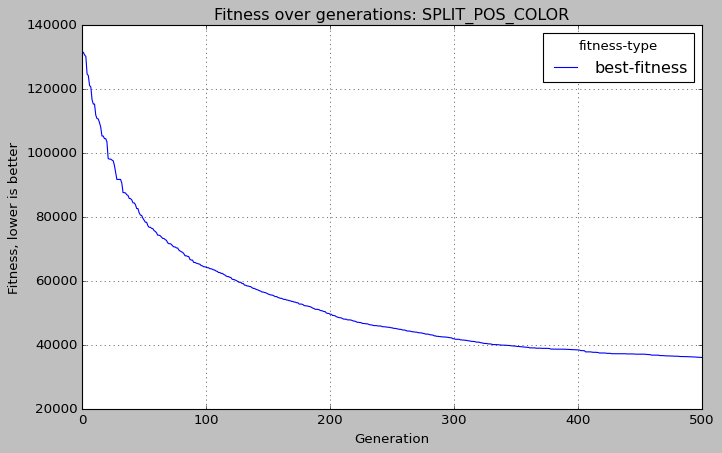

,seed,population-size,crossover-method,num-points,initialization,best-fitness,time-elapsed
499,0,100,SPLIT_POS_COLOR,100,RANDOM,36106,78.0


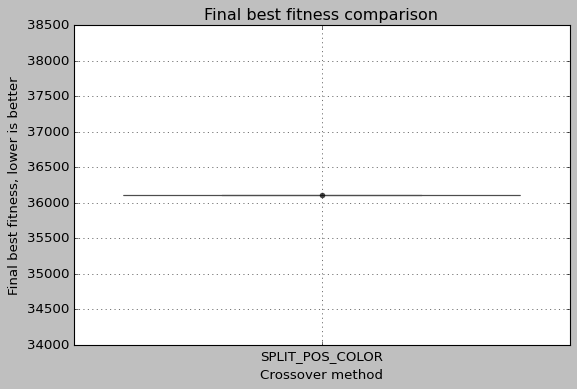

In [29]:
# your plotting code here...

# ------------------------------------------------------------
# Plot: fitness over generations
# Works whether avg-fitness exists or not
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

# Detect which fitness columns are actually available
fitness_columns = []

if "best-fitness" in df.columns:
    fitness_columns.append("best-fitness")

if "avg-fitness" in df.columns:
    fitness_columns.append("avg-fitness")

if "mean-fitness" in df.columns:
    fitness_columns.append("mean-fitness")

if "average-fitness" in df.columns:
    fitness_columns.append("average-fitness")

if len(fitness_columns) == 0:
    raise KeyError(
        "No fitness columns found. Available columns are:\n"
        + str(list(df.columns))
    )

# If multiple crossover methods exist, compare methods using best fitness
if df["crossover-method"].nunique() > 1:
    sns.lineplot(
        data=df,
        x="num-generations",
        y="best-fitness",
        hue="crossover-method",
        estimator="mean",
        ci="sd"
    )

    plt.title("Best fitness over generations")

# If only one method exists, plot whatever fitness columns are available
else:
    plot_df = df.melt(
        id_vars=["num-generations"],
        value_vars=fitness_columns,
        var_name="fitness-type",
        value_name="fitness"
    )

    sns.lineplot(
        data=plot_df,
        x="num-generations",
        y="fitness",
        hue="fitness-type"
    )

    plt.title(f"Fitness over generations: {df['crossover-method'].iloc[0]}")

plt.xlabel("Generation")
plt.ylabel("Fitness, lower is better")
plt.grid(True)
plt.show()





# ------------------------------------------------------------
# Final result summary
# ------------------------------------------------------------

group_cols = [
    "seed",
    "population-size",
    "crossover-method",
    "num-points",
    "initialization"
]

final_df = df.loc[
    df.groupby(group_cols)["num-generations"].idxmax()
].copy()

summary_cols = [
    "seed",
    "population-size",
    "crossover-method",
    "num-points",
    "initialization",
    "generation-budget",
    "best-fitness",
    "time-elapsed",
]

# Only include columns that actually exist
summary_cols = [col for col in summary_cols if col in final_df.columns]

display(final_df[summary_cols])



# ------------------------------------------------------------
# Final best fitness comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x="crossover-method",
    y="best-fitness"
)

sns.stripplot(
    data=final_df,
    x="crossover-method",
    y="best-fitness",
    color="black",
    alpha=0.7,
    jitter=True
)

plt.xlabel("Crossover method")
plt.ylabel("Final best fitness, lower is better")
plt.title("Final best fitness comparison")
plt.grid(True)
plt.show()

## Displaying the best instances over time

In [36]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, population_size, crossover_method, num_points, generation_budget = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, generation_budget + 50, 50)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_RANDOM_{generation_budget}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

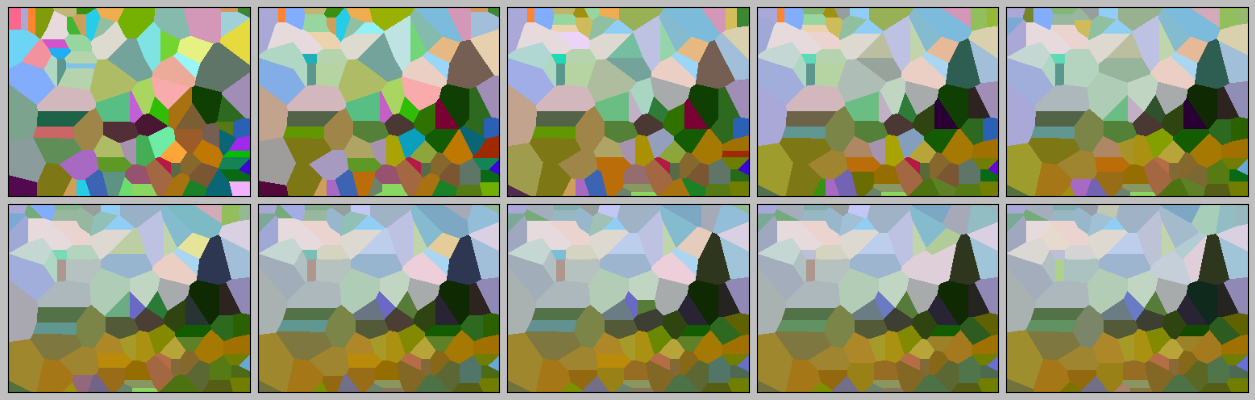

In [38]:
show_progress_over_time((0, 100, 'SPLIT_POS_COLOR', 100, 500), grid=(2,5))